# **London Crime Data Analysis and Prediction**

Acest notebook prezintă un proiect de analiză Big Data realizat în mediul Google Colab, utilizând tehnologii specifice ecosistemului Google Cloud Platform (GCP) și PySpark.

Datasetul analizat este preluat din Google BigQuery și conține informații despre infracțiunile raportate în Londra, structurate pe districte (borough), categorii de infracțiuni și perioade de timp.

**Proiectul urmărește:**

- prelucrarea și analiza datelor utilizând PySpark;
- extragerea de statistici descriptive relevante;
- identificarea unor tipare și tendințe ale criminalității;
- aplicarea și evaluarea a trei algoritmi de machine learning din librăria PySpark, în vederea realizării unor predicții asupra numărului de infracțiuni.

**Tehnologiile utilizate în cadrul proiectului:**

- Google BigQuery
- Google Colab
- PySpark
- Python

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Autentificare în Google Cloud din Colab, acces la BigQuery din contul Google.

from google.colab import auth
auth.authenticate_user()


In [3]:
# Inițializăm clientul BigQuery
from google.cloud import bigquery

client = bigquery.Client(project="la-project-tia2")

# Query: adunăm numărul de infracțiuni pe borough, categorie, an, lună
query = """
SELECT
  borough,
  major_category,
  year,
  month,
  SUM(value) AS total_crimes
FROM `bigquery-public-data.london_crime.crime_by_lsoa`
WHERE year BETWEEN 2008 AND 2016
GROUP BY borough, major_category, year, month
ORDER BY year, month
"""

df_pandas = client.query(query).to_dataframe()

# Verificare rapidă
df_pandas.head()

,borough,major_category,year,month,total_crimes
0,Haringey,Drugs,2008,1,149
1,Croydon,Sexual Offences,2008,1,30
2,Barnet,Theft and Handling,2008,1,795
3,Hammersmith and Fulham,Fraud or Forgery,2008,1,40
4,Brent,Violence Against the Person,2008,1,411


In [5]:
# Pornim Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("London Crime Big Data Analysis") \
    .getOrCreate()

# Convertim Pandas DataFrame în Spark DataFrame
crime_df = spark.createDataFrame(df_pandas)

# Verificăm
crime_df.show(5)
crime_df.printSchema()


+--------------------+--------------------+----+-----+------------+
|             borough|      major_category|year|month|total_crimes|
+--------------------+--------------------+----+-----+------------+
|            Haringey|               Drugs|2008|    1|         149|
|             Croydon|     Sexual Offences|2008|    1|          30|
|              Barnet|  Theft and Handling|2008|    1|         795|
|Hammersmith and F...|    Fraud or Forgery|2008|    1|          40|
|               Brent|Violence Against ...|2008|    1|         411|
+--------------------+--------------------+----+-----+------------+
only showing top 5 rows
root
 |-- borough: string (nullable = true)
 |-- major_category: string (nullable = true)
 |-- year: long (nullable = true)
 |-- month: long (nullable = true)
 |-- total_crimes: long (nullable = true)



In [6]:
# Numărul total de rânduri din dataset
crime_df.count()

31860

In [7]:
from pyspark.sql.functions import sum as spark_sum

crime_df.select(
    spark_sum("total_crimes").alias("total_infractiuni")
).show()

+-----------------+
|total_infractiuni|
+-----------------+
|          6447758|
+-----------------+



In [8]:
crime_by_borough = (
    crime_df
    .groupBy("borough")
    .agg(spark_sum("total_crimes").alias("total_infractiuni"))
    .orderBy("total_infractiuni", ascending=False)
)

crime_by_borough.show(10)

+-------------+-----------------+
|      borough|total_infractiuni|
+-------------+-----------------+
|  Westminster|           455028|
|      Lambeth|           292178|
|    Southwark|           278809|
|       Camden|           275147|
|       Newham|           262024|
|      Croydon|           260294|
|       Ealing|           251562|
|    Islington|           230286|
|Tower Hamlets|           228613|
|        Brent|           227551|
+-------------+-----------------+
only showing top 10 rows


In [9]:
crime_by_category = (
    crime_df
    .groupBy("major_category")
    .agg(spark_sum("total_crimes").alias("total_infractiuni"))
    .orderBy("total_infractiuni", ascending=False)
)

crime_by_category.show()

+--------------------+-----------------+
|      major_category|total_infractiuni|
+--------------------+-----------------+
|  Theft and Handling|          2661861|
|Violence Against ...|          1558081|
|            Burglary|           754293|
|     Criminal Damage|           630938|
|               Drugs|           470765|
|             Robbery|           258873|
|Other Notifiable ...|           106349|
|    Fraud or Forgery|             5325|
|     Sexual Offences|             1273|
+--------------------+-----------------+



In [10]:
crime_by_year = (
    crime_df
    .groupBy("year")
    .agg(spark_sum("total_crimes").alias("total_infractiuni"))
    .orderBy("year")
)

crime_by_year.show()

+----+-----------------+
|year|total_infractiuni|
+----+-----------------+
|2008|           738641|
|2009|           717214|
|2010|           715324|
|2011|           724915|
|2012|           737329|
|2013|           686407|
|2014|           680183|
|2015|           711624|
|2016|           736121|
+----+-----------------+



In [11]:
crime_by_month = (
    crime_df
    .groupBy("month")
    .agg(spark_sum("total_crimes").alias("total_infractiuni"))
    .orderBy("month")
)

crime_by_month.show()

+-----+-----------------+
|month|total_infractiuni|
+-----+-----------------+
|    1|           530247|
|    2|           500537|
|    3|           551795|
|    4|           520648|
|    5|           552704|
|    6|           549041|
|    7|           563076|
|    8|           532784|
|    9|           522377|
|   10|           558252|
|   11|           549671|
|   12|           516626|
+-----+-----------------+



In [12]:
# Pregătirea datelor pentru Machine Learning

# Importăm clasele necesare pentru ML din PySpark
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Selectăm doar coloanele relevante pentru predicție
ml_df = crime_df.select(
    "borough",
    "major_category",
    "year",
    "month",
    "total_crimes"
)

# Transformăm variabilele categorice (text) în valori numerice
borough_indexer = StringIndexer(
    inputCol="borough",
    outputCol="borough_index",
    handleInvalid="keep"
)

category_indexer = StringIndexer(
    inputCol="major_category",
    outputCol="category_index",
    handleInvalid="keep"
)

# Combinăm toate variabilele de intrare într-un vector de features
assembler = VectorAssembler(
    inputCols=["borough_index", "category_index", "year", "month"],
    outputCol="features"
)

# Pipeline = pașii de preprocesare executați în ordine
pipeline = Pipeline(stages=[
    borough_indexer,
    category_indexer,
    assembler
])

# Aplicăm pipeline-ul pe date
ml_ready_df = pipeline.fit(ml_df).transform(ml_df)

# Selectăm datele finale pentru ML
final_df = ml_ready_df.select("features", "total_crimes")

# Verificăm structura finală
final_df.show(5)

+--------------------+------------+
|            features|total_crimes|
+--------------------+------------+
|[12.0,2.0,2008.0,...|         149|
|[6.0,8.0,2008.0,1.0]|          30|
|[1.0,5.0,2008.0,1.0]|         795|
|[11.0,7.0,2008.0,...|          40|
|[3.0,6.0,2008.0,1.0]|         411|
+--------------------+------------+
only showing top 5 rows


In [13]:
# Împărțim datele în set de antrenare și testare
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

# Verificăm dimensiunile
print("Train:", train_df.count())
print("Test:", test_df.count())


Train: 25628
Test: 6232


In [14]:
# Antrenăm 3 modele de regresie și le evaluăm (RMSE + R2)

# Importăm modelele de regresie
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor

# Importăm evaluatorul pentru regresie
from pyspark.ml.evaluation import RegressionEvaluator

# Definim evaluatorii (RMSE și R2)
rmse_evaluator = RegressionEvaluator(
    labelCol="total_crimes",
    predictionCol="prediction",
    metricName="rmse"
)

r2_evaluator = RegressionEvaluator(
    labelCol="total_crimes",
    predictionCol="prediction",
    metricName="r2"
)

In [15]:
# MODEL 1: Linear Regression (regresie liniară)

lr = LinearRegression(
    featuresCol="features",
    labelCol="total_crimes"
)

# Antrenăm modelul pe setul de training
lr_model = lr.fit(train_df)

# Facem predicții pe setul de test
lr_predictions = lr_model.transform(test_df)

# Evaluăm modelul
lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression -> RMSE:", lr_rmse, "| R2:", lr_r2)

# Vedem câteva predicții vs valori reale
lr_predictions.select("total_crimes", "prediction").show(10)

Linear Regression -> RMSE: 292.39828026944207 | R2: -5.999295288416917e-05
+------------+------------------+
|total_crimes|        prediction|
+------------+------------------+
|         140|198.03043129588104|
|         151|199.03772745055778|
|         144| 199.5413755278961|
|         210|197.44895838919206|
|         168| 198.9599026212071|
|         203|199.96719877588384|
|         177|198.12660567584896|
|         151|  199.637549907864|
|         201|198.80425296250576|
|         229|199.05607700117503|
+------------+------------------+
only showing top 10 rows


In [16]:
# MODEL 2: Decision Tree Regressor (arbore de decizie) - FIX maxBins

from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="total_crimes",
    maxDepth=10,
    maxBins=64
)

# Antrenăm modelul
dt_model = dt.fit(train_df)

# Predicții pe test
dt_predictions = dt_model.transform(test_df)

# Evaluare
dt_rmse = rmse_evaluator.evaluate(dt_predictions)
dt_r2 = r2_evaluator.evaluate(dt_predictions)

print("Decision Tree -> RMSE:", dt_rmse, "| R2:", dt_r2)

# Predicții vs valori reale
dt_predictions.select("total_crimes", "prediction").show(10)

Decision Tree -> RMSE: 40.686338618927685 | R2: 0.9806369554645216
+------------+-----------------+
|total_crimes|       prediction|
+------------+-----------------+
|         140|194.1578947368421|
|         151|194.1578947368421|
|         144|194.1578947368421|
|         210|194.1578947368421|
|         168|194.1578947368421|
|         203|194.1578947368421|
|         177|194.1081081081081|
|         151|194.1081081081081|
|         201|194.1081081081081|
|         229|194.1081081081081|
+------------+-----------------+
only showing top 10 rows


In [17]:
# MODEL 3: Random Forest Regressor (pădure aleatoare) - FIX maxBins

from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_crimes",
    numTrees=50,
    maxDepth=10,
    maxBins=64,
    seed=42
)

# Antrenăm modelul
rf_model = rf.fit(train_df)

# Predicții pe test
rf_predictions = rf_model.transform(test_df)

# Evaluare
rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest -> RMSE:", rf_rmse, "| R2:", rf_r2)

# Predicții vs valori reale
rf_predictions.select("total_crimes", "prediction").show(10)

Random Forest -> RMSE: 40.67013617103614 | R2: 0.9806523742150379
+------------+------------------+
|total_crimes|        prediction|
+------------+------------------+
|         140|191.88498136586776|
|         151|183.25637768169244|
|         144| 181.8763793769191|
|         210|195.81068173062985|
|         168|184.42535997687412|
|         203|193.40309791300558|
|         177|178.06482026640515|
|         151| 193.9219245974494|
|         201|183.55396556166167|
|         229|195.04967512174736|
+------------+------------------+
only showing top 10 rows


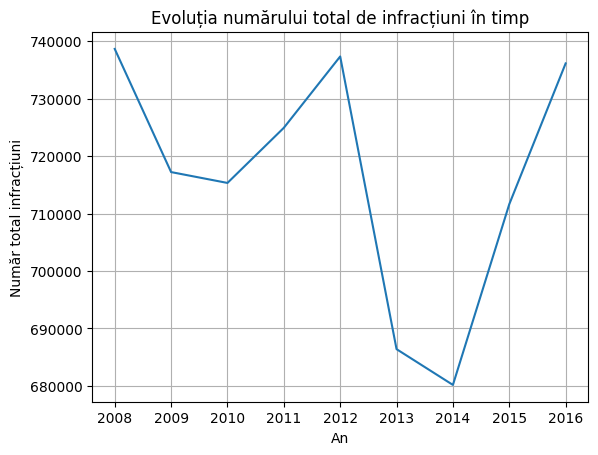

In [21]:
# Evoluția infracțiunilor în timp
trend_df = crime_df.groupBy("year").sum("total_crimes").orderBy("year")
trend_pd = trend_df.toPandas()

plt.figure()
plt.plot(trend_pd["year"], trend_pd["sum(total_crimes)"])
plt.title("Evoluția numărului total de infracțiuni în timp")
plt.xlabel("An")
plt.ylabel("Număr total infracțiuni")
plt.grid(True)
plt.show()

In [19]:
crime_df.printSchema()
crime_df.show(5)

root
 |-- borough: string (nullable = true)
 |-- major_category: string (nullable = true)
 |-- year: long (nullable = true)
 |-- month: long (nullable = true)
 |-- total_crimes: long (nullable = true)

+--------------------+--------------------+----+-----+------------+
|             borough|      major_category|year|month|total_crimes|
+--------------------+--------------------+----+-----+------------+
|            Haringey|               Drugs|2008|    1|         149|
|             Croydon|     Sexual Offences|2008|    1|          30|
|              Barnet|  Theft and Handling|2008|    1|         795|
|Hammersmith and F...|    Fraud or Forgery|2008|    1|          40|
|               Brent|Violence Against ...|2008|    1|         411|
+--------------------+--------------------+----+-----+------------+
only showing top 5 rows


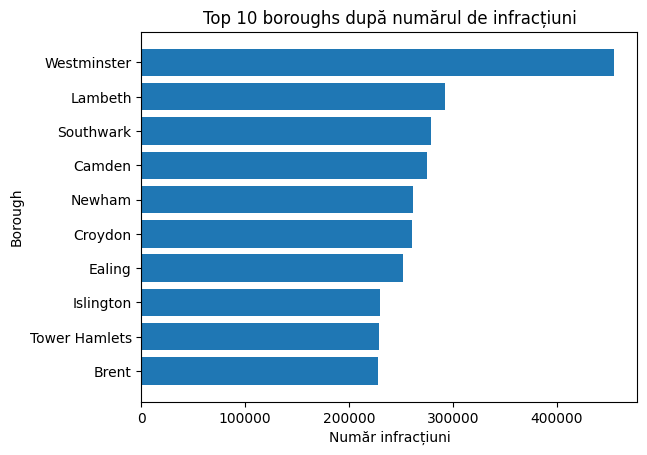

In [22]:
# Top 10 boroughs după infracțiuni
top_boroughs = crime_df.groupBy("borough").sum("total_crimes") \
    .orderBy("sum(total_crimes)", ascending=False) \
    .limit(10)

top_boroughs_pd = top_boroughs.toPandas()

plt.figure()
plt.barh(top_boroughs_pd["borough"], top_boroughs_pd["sum(total_crimes)"])
plt.title("Top 10 boroughs după numărul de infracțiuni")
plt.xlabel("Număr infracțiuni")
plt.ylabel("Borough")
plt.gca().invert_yaxis()
plt.show()

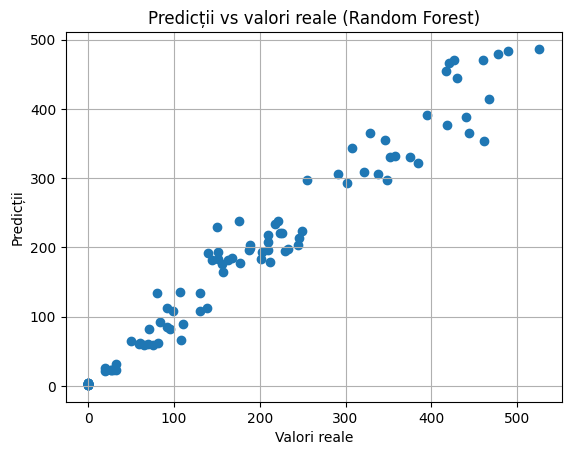

In [23]:
# Predicții vs valori reale – Random Forest
pred_pd = rf_predictions.select("total_crimes", "prediction").limit(100).toPandas()

plt.figure()
plt.scatter(pred_pd["total_crimes"], pred_pd["prediction"])
plt.xlabel("Valori reale")
plt.ylabel("Predicții")
plt.title("Predicții vs valori reale (Random Forest)")
plt.grid(True)
plt.show()